In [ ]:
%pip install psycopg2-binary python-dotenv pandas matplotlib


   ---------------------------------------- 0.0/1.2 MB ? eta -:--:--
   ---------------------------------------- 1.2/1.2 MB 14.3 MB/s eta 0:00:00
   ---------------------------------------- 0.0/11.5 MB ? eta -:--:--
   ----------------------- ---------------- 6.8/11.5 MB 34.9 MB/s eta 0:00:01
   ---------------------------------------  11.3/11.5 MB 32.0 MB/s eta 0:00:01
   ---------------------------------------- 11.5/11.5 MB 23.2 MB/s eta 0:00:00


ERROR: Could not install packages due to an OSError: [WinError 5] Access is denied: 'z:\\Dev\\UTFPR\\icia\\venv\\Lib\\site-packages\\psycopg2\\_psycopg.cp312-win_amd64.pyd'
Check the permissions.


[notice] A new release of pip is available: 24.2 -> 24.3.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [5]:
import psycopg2
from dotenv import load_dotenv
import os

# Define your connection parameters
# Load environment variables from .env file
load_dotenv('icia/.env')

# Define your connection parameters
conn_params = {
    'dbname': os.getenv('DBNAME'),
    'user': os.getenv('DBUSER'),
    'password': os.getenv('DBPASS'),
    'host': os.getenv('DBHOST'),
    'port': os.getenv('DBPORT')
}

try:
    conn = psycopg2.connect(**conn_params)
    print("Connection to PostgreSQL established successfully.")
except Exception as e:
    print(f"Error: {e}")



Connection to PostgreSQL established successfully.


In [9]:
import pandas as pd

# Create a cursor object
cur = conn.cursor()

# Execute the query
cur.execute('SELECT * FROM polls_agent')

# Fetch all rows from the executed query
rows = cur.fetchall()

# Get column names from the cursor
colnames = [desc[0] for desc in cur.description]

# Create a DataFrame from the fetched rows
df = pd.DataFrame(rows, columns=colnames)

# Close the cursor
cur.close()

# Display the DataFrame
print(df)

    id  user_id  score
0   12        1    461
1   15        1    417
2   19        1    545
3   23        1    585
4   26        1    395
5    2        1    199
6   29        1    497
7   33        1    639
8   20        1    534
9   13        1    564
10  37        1    607
11  41        1    619
12  24        1    547
13  10        1    493
14  17        1    489
15  14        1    433
16  27        1    573
17  21        1    577
18  30        1    497
19  11        1    493
20  34        1    615
21  18        1    491
22  25        1    575
23  38        1    395
24  28        1    565
25  22        1    589
26  42        1    585
27  31        1    689
28  35        1    515
29  39        1    525
30  32        1    477
31  43        1    567
32  36        1    399
33  40        1    591
34  68        1    642
35   1        1    300
36  82        1    531


In [12]:
# Create a cursor object
cur = conn.cursor()

# Execute the join query
cur.execute('''
    SELECT a.*, c.*
    FROM polls_agent a
    JOIN polls_crowd c ON a.id = c.agent_id
''')

# Fetch all rows from the executed query
joined_rows = cur.fetchall()

# Get column names from the cursor
joined_colnames = [desc[0] for desc in cur.description]

# Create a DataFrame from the fetched rows
crowd_df = pd.DataFrame(joined_rows, columns=joined_colnames)

# Close the cursor
cur.close()

# Display the joined DataFrame
print(crowd_df)

    id  user_id  score                               email  \
0   12        1    461          igorcarneiro6661@gmail.com   
1   15        1    417        augusto.cesar.lima@gmail.com   
2   19        1    545                    teste@123.com.it   
3   23        1    585                      teste@prod.com   
4   26        1    395                          ggg@gg.com   
5   33        1    639                  lgb25445@dcobe.com   
6   20        1    534                 testeno@celular.com   
7   13        1    564      kathlynsantosleticia@gmail.com   
8   37        1    607              edison_msj@hotmail.com   
9   41        1    619                      aaaa@gmail.com   
10  24        1    547                      salles3@me.com   
11  17        1    489                     buconho@bol.com   
12  14        1    433     daniel.d.salles@bradesco.com.br   
13  27        1    573                      joao@email.com   
14  21        1    577                           123@4.com   
15  30  

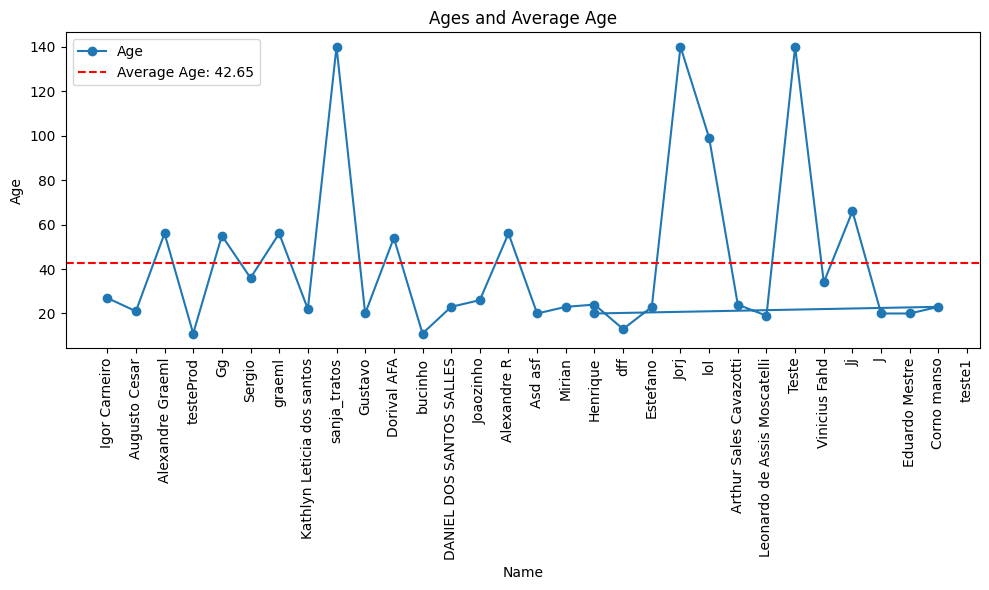

In [13]:
import matplotlib.pyplot as plt

# Plot the ages
plt.figure(figsize=(10, 6))
plt.plot(crowd_df['name'], crowd_df['age'], marker='o', linestyle='-', label='Age')

# Calculate and plot the average age
average_age = crowd_df['age'].mean()
plt.axhline(y=average_age, color='r', linestyle='--', label=f'Average Age: {average_age:.2f}')

# Add labels and title
plt.xlabel('Name')
plt.ylabel('Age')
plt.title('Ages and Average Age')
plt.xticks(rotation=90)
plt.legend()

# Show the plot
plt.tight_layout()
plt.show()
